In [ ]:
from pathlib import Path
import yaml
import os 
os.chdir(Path('/gpfs-calypso/home/globc/garcia/'))
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
import numpy as np
import xarray as xr
from scipy import stats


from scenarIA.src.data.dataloader import get_climatology
from scenarIA.src.utils.evalutils import EvaluationPlots, compare_temporal_profiles, compare_metrics_maps, compare_metrics
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean
from scenarIA.src.utils.settings import PREDICTIONS_DIR, DATASET_DIR, GRAPHS_DIR, CONFIG_DIR, SIMUS_COLORS_DICT

In [23]:
with open(CONFIG_DIR / 'plots.yaml') as file:
    config_plots = yaml.safe_load(file)
    
config_plots['pr']['lim']['mean_error'] = [-0.6, 0.6] # 0.6 pour ssp245 et 1. pour ssp370
config_plots['pr']['lim']['values'] = [-2.4, 2.4]
config_plots['pr']['lim']['std'] = [0, 0.25] # 0.25 pour ssp245 et 0.3 pour ssp370

var_name = 'pr'
true_simu = 'ssp245'
color = 'royalblue'
save_dir = GRAPHS_DIR/ f'runs/MPI-ESM1-2-LR/annual' # or None
#save_dir = None
title_base = f'MPI-ESM1-2-LR_annual_{true_simu}'

In [26]:
# Open climatology file
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_piControl.nc').mean('member')
clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')[var_name].values

# Open true projection file
true = xr.open_dataset( DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{true_simu}.nc').mean('member')
lats = true.lat.values
t = true.time.values
y = true[var_name].values - clim

# Open prediction files to compare
c7 = xr.open_dataset(PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/exp9/MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convlstm_seq5_mem30_epoch100.nc')['pr'].values - clim





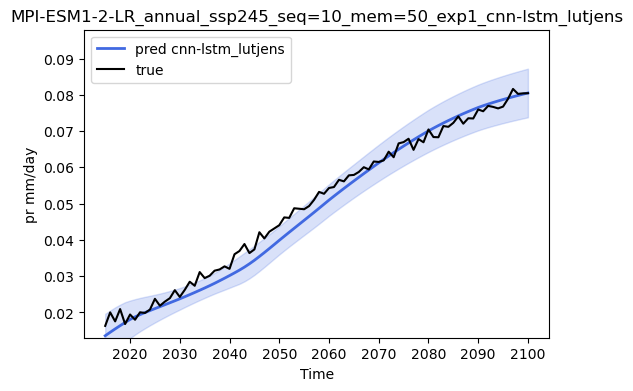

In [27]:
# Figure : Temporal profile for 1 test

# Create a dictionary with all tests (if multiples runs, create a list of len(y_hat) = runs)
y_hat_dict = {
    'cnn-lstm_lutjens': [c6[run] for run in range(c6.shape[0])],
  }

for key, value in y_hat_dict.items():
    mini_dict = {key:value}
    color_dict = {key: color}
    title = title_base + f'_{key}'
    compare_temporal_profiles(y, mini_dict, t, var_name, lats, point=None, window_size=None, config_plots=config_plots, colors=color_dict, title=title, save_dir=save_dir)

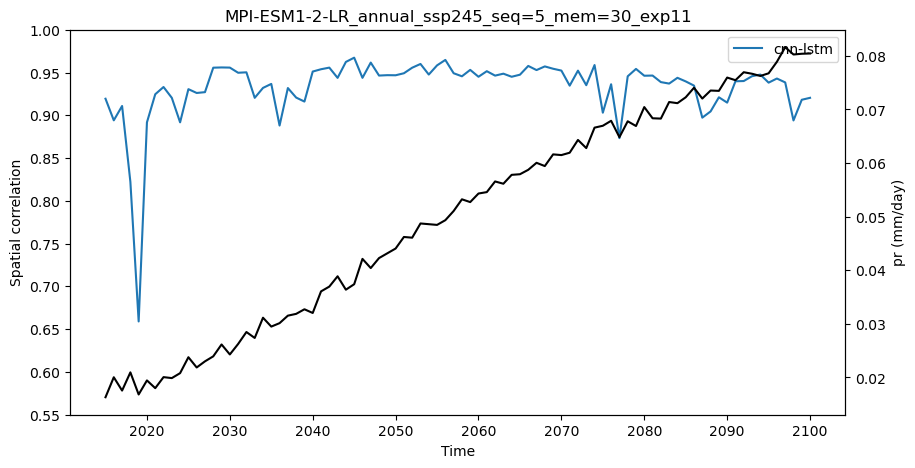

In [17]:
# Figure : Correlation spatiale

fig, ax1 = plt.subplots(figsize = (10,5))
for key, value in y_hat_dict.items():
    data = np.stack(value, axis=0)
    corr_list = []
    for run in range(data.shape[0]):
        data_seed = data[run]
        corr = [stats.pearsonr(y[i].flatten(), data_seed[i, ...].flatten()).statistic for i in range(y.shape[0])]
        corr_list.append(corr)
    corr_mean = np.stack(corr_list,axis=0).mean(axis=0)
    ax1.plot(t, corr_mean, label=key)
    ax1.set_title(title_base)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Spatial correlation')
    ax1.set_ylim(0.55,1)
ax2 = ax1.twinx() 
ax2.plot(t, weighted_global_mean(y, lats), color = 'k')
ax2.set_ylabel('pr (mm/day)')
ax1.legend()
fig.savefig(save_dir/f'{title_base}_spatial_correlation.png')



evalllll
(21, 96, 192)


KeyboardInterrupt: 

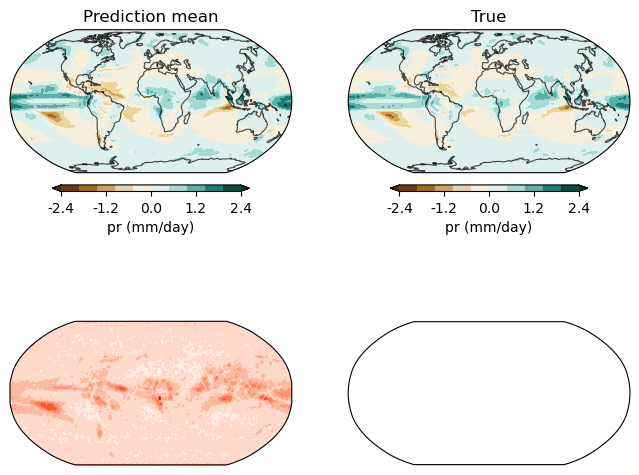

In [11]:
# Figure : Plot map errors for 1 test

eval_func = EvaluationPlots(config_plots=config_plots,
                                        simulation_name=true_simu,var_name=var_name)
y = y[-21:, : ,:]
save_dir=None
for i, y_hat in enumerate([c5]): # TODO : change if usefull
    exp = list(y_hat_dict.keys())[i]
    eval_func.plot_diff_maps(y, 
                            y_hat.mean(axis=0)[-21:,:,:], 
                            y_hat.std(axis=0)[-21:,:,:], 
                            title=f'{exp} {true_simu} (2080-2100)',
                             no_limits=False,
                            save_path=save_dir + title_base + f'diff_maps_pr_seq5_mem30_{exp}.png' if save_dir else None)
    

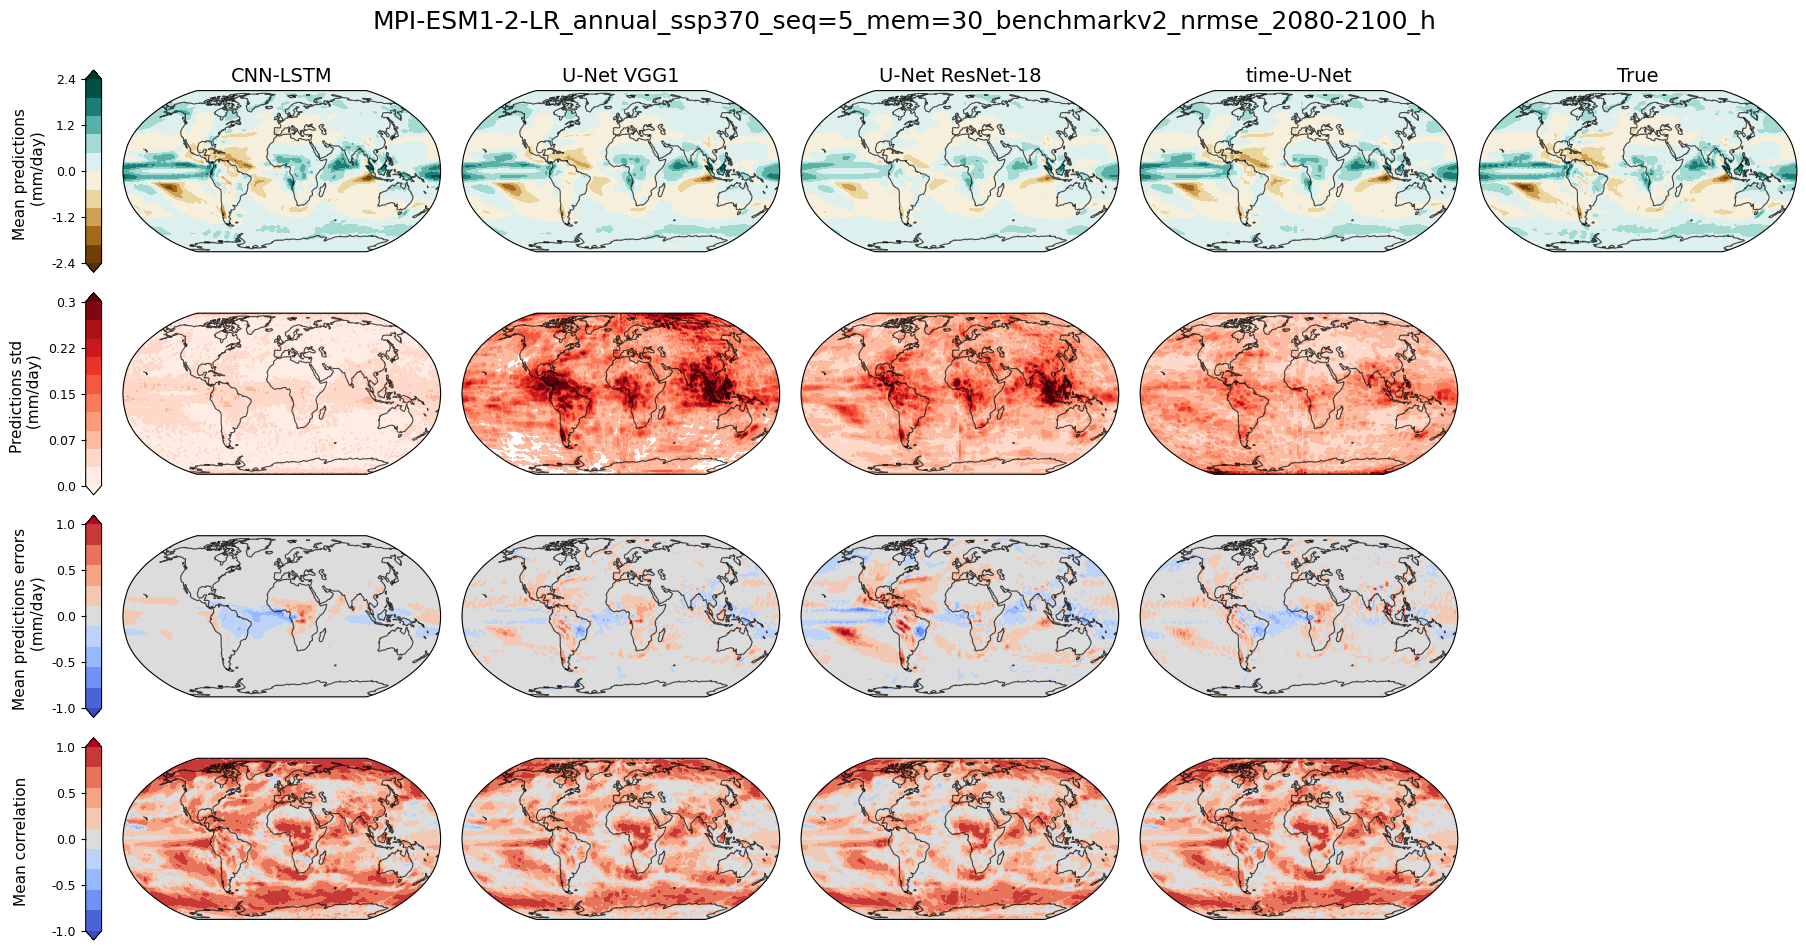

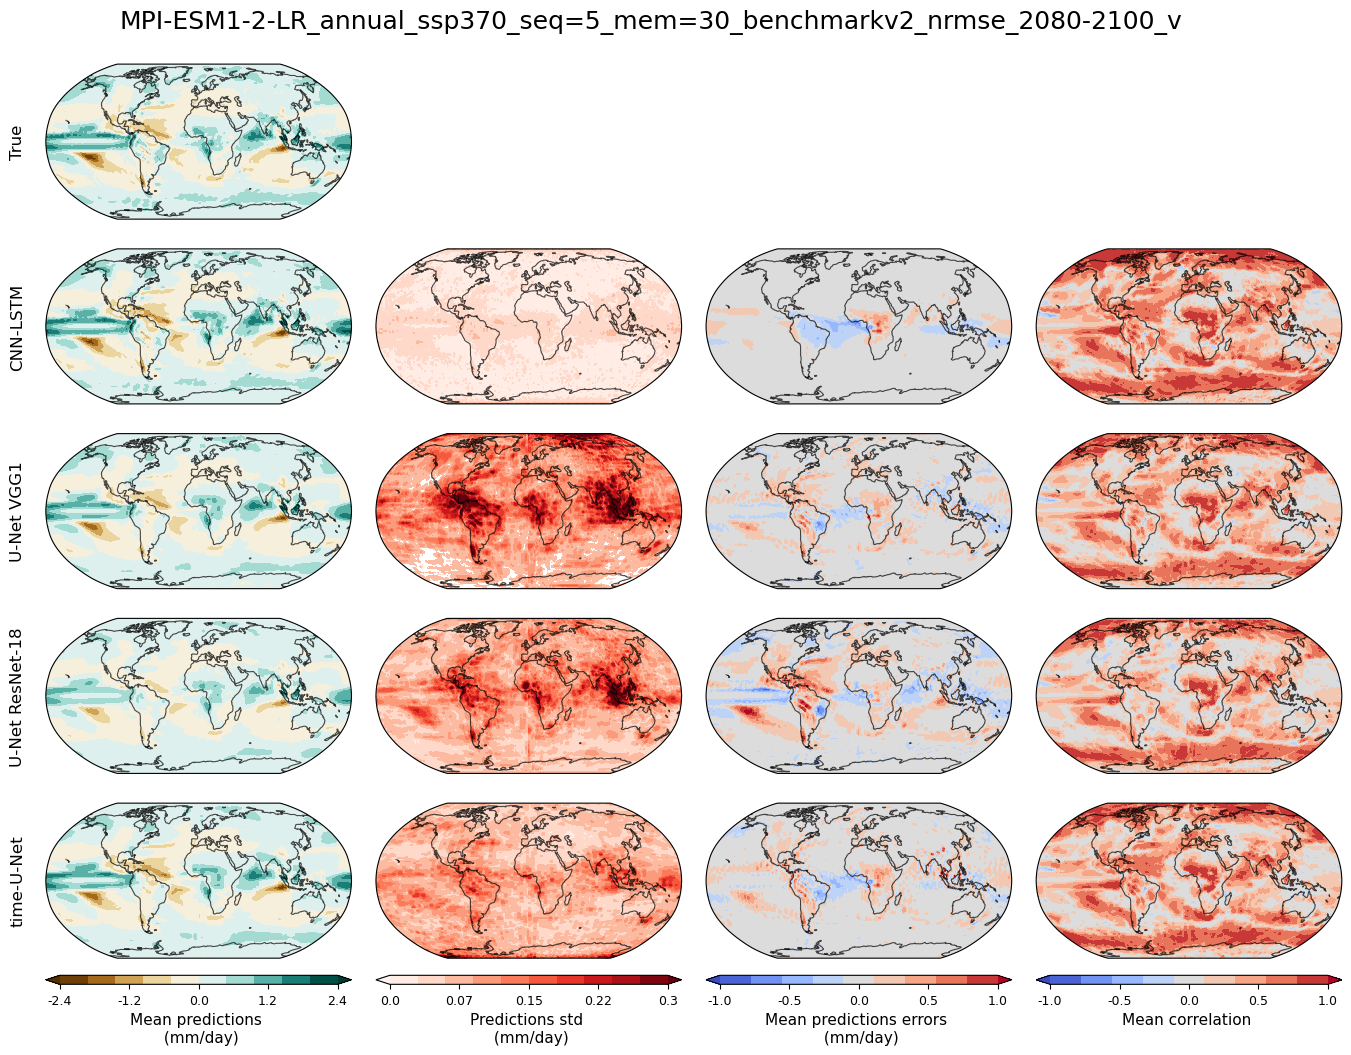

In [8]:
# Figure : Compare map errors between tests


y_hat_dict = {
    'CNN-LSTM': [c5[run] for run in range(c5.shape[0])],
    'U-Net VGG1': [c6[run] for run in range(c6.shape[0])],
    'U-Net ResNet-18': [c7[run] for run in range(c7.shape[0])],
    'time-U-Net': [c8[run] for run in range(c8.shape[0])],
  }
y = y[-21:, :, :]
for key, y_hat in y_hat_dict.items():
    y_hat_dict[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics_maps(y, 
                    y_hat_dict, 
                    var_name=var_name, 
                    title=f'{title_base}_nrmse_2080-2100_h', 
                    save_dir=save_dir,
                    config_plots=config_plots)
compare_metrics_maps(y, 
                    y_hat_dict, 
                    var_name=var_name, 
                    title=f'{title_base}_nrmse_2080-2100_v',
                     save_dir=save_dir,
                    config_plots=config_plots,
                    orientation='vertical')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(86, 96, 192)
['cnn-lstm exp1 lutjens', 'cnn-lstm exp9'] = [1.621224474474338, 1.8367181760156228] with 95% CI [[1.316828977185627, 1.5115761583815808], [1.877341212545881, 2.2322457677008796]]
['cnn-lstm exp1 lutjens', 'cnn-lstm exp9'] = [1.4087262223663017, 1.523828197207514] with 95% CI [[1.203301918497808, 1.3776267888589877], [1.5613066535957532, 1.7833509620684074]]
['cnn-lstm exp1 lutjens', 'cnn-lstm exp9'] = [0.04249965042160721, 0.06257799576162174] with 95% CI [[0.01639250140922779, 0.026693307799166448], [0.06927717265244375, 0.11992661777436896]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['cnn-lstm exp1 lutjens', 'cnn-lstm exp9'] = [0.10563294353769855, 0.114263833072115] with 95% CI [[0.0902292593105661, 0.1033009611754945], [0.11707414468886683, 0.13372407533355976]]
['cnn-lstm exp1 lutjens', 'cnn-lstm exp9'] = [0.0031868244532401563, 0.004692393587936558] with 95% CI [[0.0012291871538346003, 0.002001590252822433], [0.005194729501772662, 0.008992664041383222]]


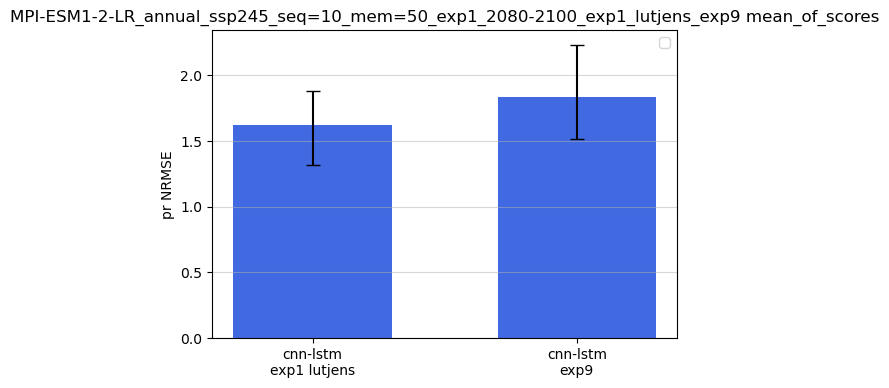

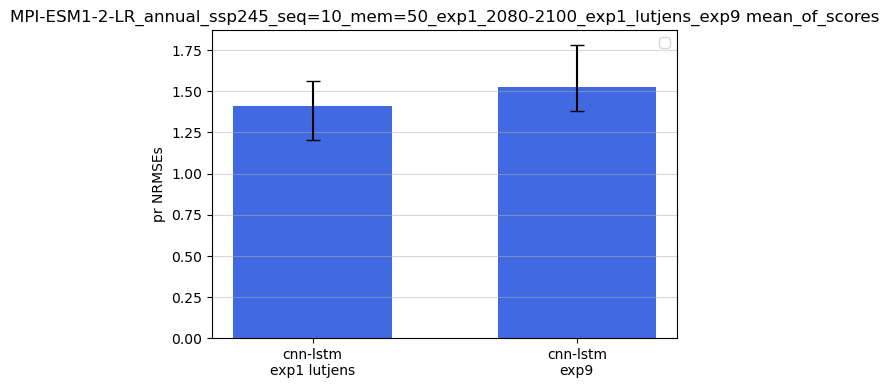

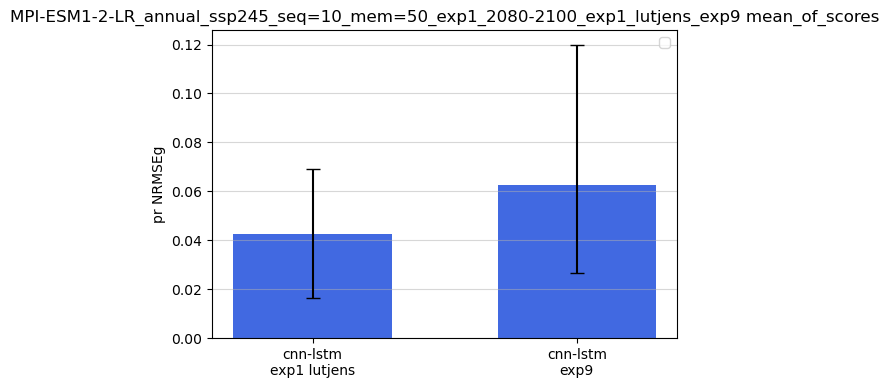

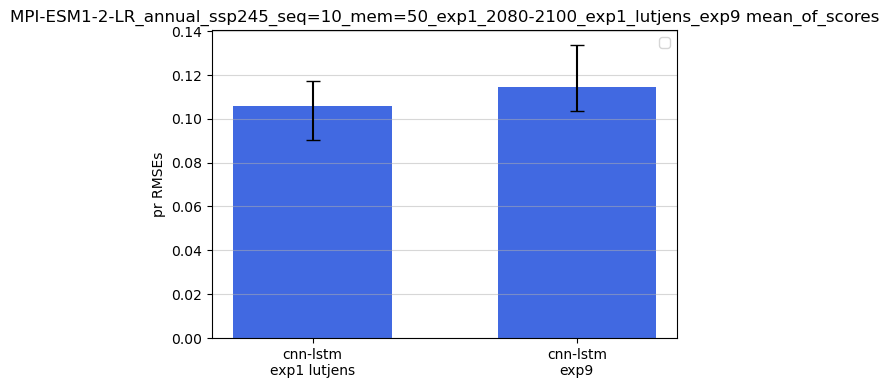

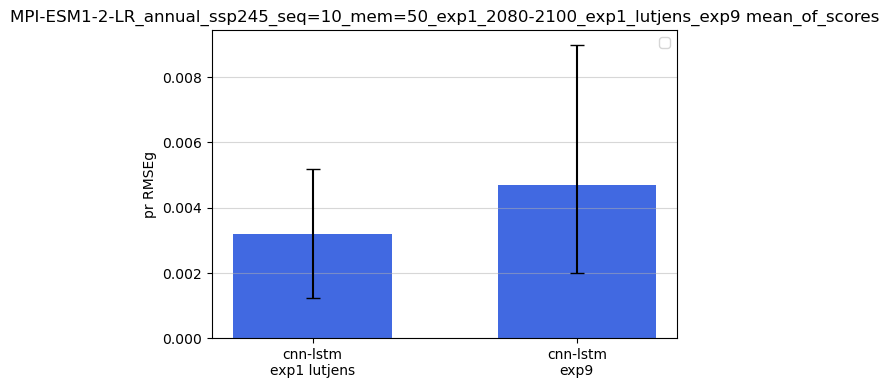

In [28]:
## Compute NRMSE
print(y.shape)
y_hat_dict = {
    'exp1': [c5[run] for run in range(c5.shape[0])],
    'exp5': [c6[run] for run in range(c6.shape[0])],
    'exp9': [c7[run] for run in range(c7.shape[0])],
    'exp11': [c8[run] for run in range(c8.shape[0])],
    'exp6': [c9[run] for run in range(c9.shape[0])]
  }
y_hat_dict = {
    'cnn-lstm exp1 lutjens': [c6[run] for run in range(c6.shape[0])],
    'cnn-lstm exp9': [c7[run] for run in range(c7.shape[0])],
  }


y = y[-21:, :, :]
for key, y_hat in y_hat_dict.items(): 
    y_hat_dict[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics(y, 
                y_hat_dict, 
                lats=lats, 
                var_name=var_name, 
                title=f'{title_base}_2080-2100_exp1_lutjens_exp9', 
                save_dir=save_dir, 
                ensemble_scoring='mean_of_scores',
                figsize=(6,4),
                colors=color ,
                labels=None)

## Cross validation

In [3]:
simu_dict = {'ssp126': 'SSP1-2.6', 
              'ssp245': 'SSP2-4.5', 
              'ssp370':'SSP3-7.0', 
              'ssp585': 'SSP5-8.5'}
def plot_mean_std_simulations(files_dict,
                                var_name,
                                colors_dict=None,
                                vmin=None,
                                vmax=None,
                                time_res = 'Y',
                                title=None,
                                save_path=None):

    
    plt.figure(figsize=(6, 5)) 
    for simu, files in files_dict.items():
        if isinstance(files, str) or isinstance(files, Path):
            files = [files]
        color = colors_dict[simu] if colors_dict else None
        time = []
        mean = []
        std = []
        for file in files:
            if time_res == 'm':
                ds = xr.open_dataset(file, chunks= {'time':12})
                ds = dataset_xr_formatting(ds, original_time_format = "%Y%m")
                ds = ds[var_name].groupby('time.year').mean('time').rename({'year': 'time'})
        
            else:
                ds = xr.open_dataset(file)
                ds = dataset_xr_formatting(ds, original_time_format = "%Y")
                ds = ds[var_name]
            
            unit = ds.attrs["units"]       
            ds = ds - clim[var_name]
            ds = weighted_global_mean(ds)

            time.append(ds.time.values)
            if 'run' in ds.dims:
                mean.append(ds.mean('run').values)
                std.append(ds.std('run').values)
            else:
                mean.append(ds.values)
                std.append(np.zeros_like(ds.values))
            ds.close()
        time = np.concatenate(time)
        mean = np.concatenate(mean)
        std = np.concatenate(std)
        if simu == 'ssp126':
            plt.plot(time, mean, label='Predictions mean', color=color, linestyle = '--', linewidth=1, alpha=0.6)
            plt.fill_between(time, mean - std, mean + std, alpha=0.2, color=color, label ='Predictions 2*std')
        else:
            plt.plot(time, mean, color=color, linestyle = '--', linewidth=1, alpha=0.6)
            plt.fill_between(time, mean - std, mean + std, alpha=0.2, color=color)

        # Add true simulation
        ds_true = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{simu}.nc')[var_name].mean('member') - clim[var_name]
        ds_true = weighted_global_mean(ds_true)
        simu_name = simu_dict[simu]
        plt.plot(time, ds_true.values , label=simu_name, color=color, linewidth=2)

    plt.grid(axis='y', alpha = 0.5)
    plt.ylabel(f'{var_name} {unit}')
    plt.ylim(vmin, vmax)
    plt.legend(loc ='upper left')
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)

{'ssp126': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp2/MPI-ESM1-2-LR_annual_exp2_ssp126_pr_cnn-lstm_seq5_mem50_sub1.nc', 'ssp245': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp1/MPI-ESM1-2-LR_annual_exp1_ssp245_pr_cnn-lstm_seq5_mem50_sub1.nc', 'ssp370': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp3/MPI-ESM1-2-LR_annual_exp3_ssp370_pr_cnn-lstm_seq5_mem50_sub1.nc', 'ssp585': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp4/MPI-ESM1-2-LR_annual_exp4_ssp585_pr_cnn-lstm_seq5_mem50_sub1.nc'}


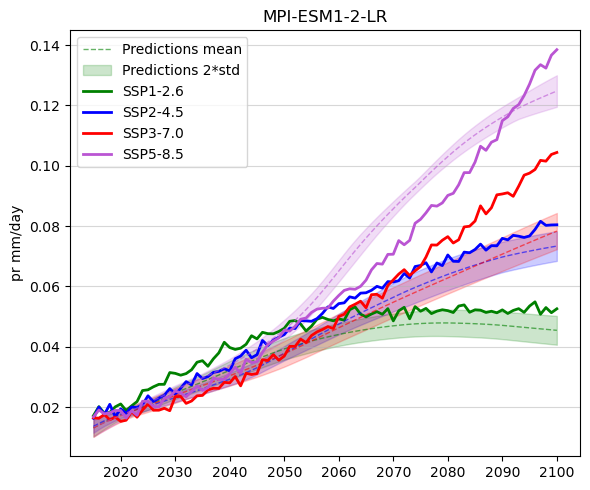

In [4]:
simus = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
files_dict = {}
colors_dict = {'ssp126': 'green', 
              'ssp245': 'b', 
              'ssp370':'r', 
              'ssp585': 'mediumorchid'}
exp_dict = {'ssp126': 'exp2', 
              'ssp245': 'exp1', 
              'ssp370':'exp3', 
              'ssp585': 'exp4'}
vmin = {'tas': None, 'pr': None}
vmax = {'tas': None, 'pr': None}
for var_name in ['pr']:
    for simu in simus:
        files_dict[simu] = glob.glob(str(PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/*/*{simu}_{var_name}*seq5_*.nc'))[0]
    plot_mean_std_simulations(files_dict,
                              var_name=var_name,
                              colors_dict = colors_dict,
                              title='MPI-ESM1-2-LR',
                              vmin=vmin[var_name],
                              vmax=vmax[var_name],
                              save_path= GRAPHS_DIR / f'runs/MPI-ESM1-2-LR/annual/{var_name}_temporal_profiles_cross_validation.png'
                              )
print(files_dict)

evalllll
(96, 192)
(96, 192)
(96, 192)
(96, 192)
evalllll
(96, 192)
(96, 192)
(96, 192)


KeyboardInterrupt: 

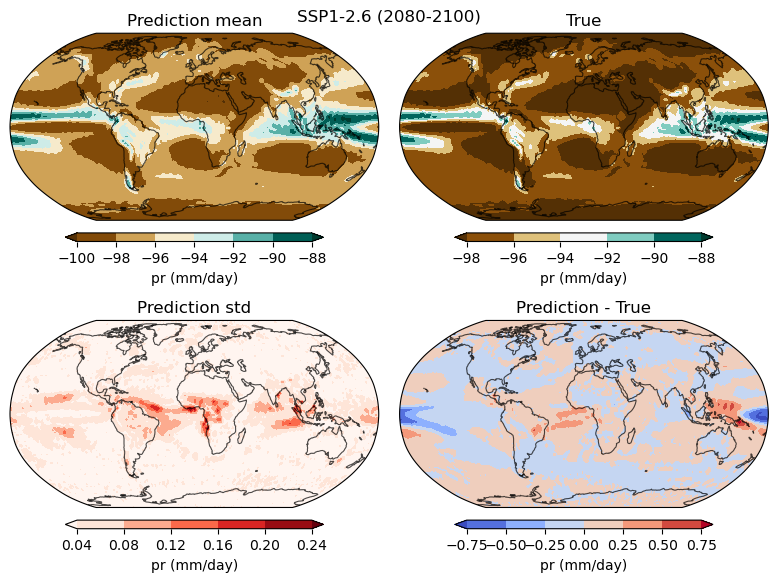

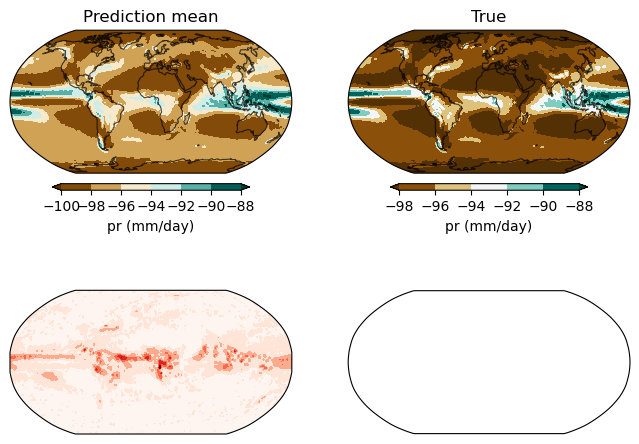

In [16]:

with open(CONFIG_DIR / 'plots.yaml') as file:
    config_plots = yaml.safe_load(file)
    
config_plots['tas']['lim']['mean_error'] = [-2,2]
config_plots['tas']['lim']['values'] = [0, 14]
config_plots['pr']['lim']['std'] = [0, 0.6]
config_plots['pr']['lim']['mean_error'] = [-1.2,1.2]
config_plots['pr']['lim']['values'] = [-2.4, 2.4]
config_plots['pr']['lim']['std'] = [0, 0.25]

for var_name in ['pr']:
    for simu in simus:
        simu_name = simu_dict[simu]
        exp = exp_dict[simu]
        if var_name == 'pr':
            exp = 'seq5_mem50'
        elif var_name == 'tas':
            exp = 'seq10_mem30'
        files_dict[simu] = glob.glob(str(PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/*/*{simu}_{var_name}*{exp}*.nc'))[0]
       
        eval_func = EvaluationPlots(config_plots=config_plots,
                                        simulation_name=simu,
                                        var_name=var_name)
        y = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{simu}.nc')[var_name].mean('member').sel(time=slice('2080', '2100')) - clim[var_name] / clim[var_name] *100
        y_hat = xr.open_dataset(files_dict[simu])[var_name].sel(time=slice('2080', '2100')) - clim[var_name] / clim[var_name] * 100
        
        save_path = GRAPHS_DIR/ f'runs/MPI-ESM1-2-LR/annual/{exp}/MPI-ESM1-2-LR_annual_{exp}_{simu}_relative_diff_maps_{var_name}_{exp}.png'                                                                                                             
        eval_func.plot_diff_maps(y.values, 
                                y_hat.mean('run').values, 
                                y_hat.std('run').values, 
                                title=f'{simu_name} (2080-2100)',
                                 no_limits=True,
                                save_path=save_path)